# 02c · Exploratory Data Analysis

Before modelling I inspect the training data itself. Each figure below is saved to
`results/eda/` and answers one question about the ~23,300 nationally-sampled,
Hansen-labelled pixels and their 17 Sentinel-2 / Sentinel-1 / SRTM features.

In [1]:
import json, warnings
from pathlib import Path
import numpy as np, pandas as pd, matplotlib.pyplot as plt, seaborn as sns
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import precision_recall_curve, average_precision_score
warnings.filterwarnings("ignore")

ROOT = Path.cwd() if (Path.cwd()/'data').exists() else Path.cwd().parent
OUT = ROOT/'results'/'eda'; OUT.mkdir(parents=True, exist_ok=True)
GREEN, RED = '#16a34a', '#dc2626'

df = pd.read_csv(ROOT/'data'/'raw'/'training_data_national.csv')
geo = df['.geo'].apply(lambda s: json.loads(s)['coordinates'])
df['lng'], df['lat'] = geo.apply(lambda c: c[0]), geo.apply(lambda c: c[1])
FEATURES = ['EVI_train','NBR_train','NDVI_change','NDVI_test','NDVI_train','NIR_train',
            'RED_train','SWIR_test','SWIR_train','VH_VV_ratio','VH_test','VH_train',
            'VV_test','VV_train','aspect','elevation','slope']
X = df[FEATURES].replace(-9999, np.nan); X = X.fillna(X.median()); y = df['label'].values
print(f'{len(df):,} pixels, {len(FEATURES)} features, classes={df.label.value_counts().to_dict()}')

23,319 pixels, 17 features, classes={1: 12003, 0: 11316}


### 1 · Class balance
The stratified sample is near 1:1, so no class weighting is needed downstream.

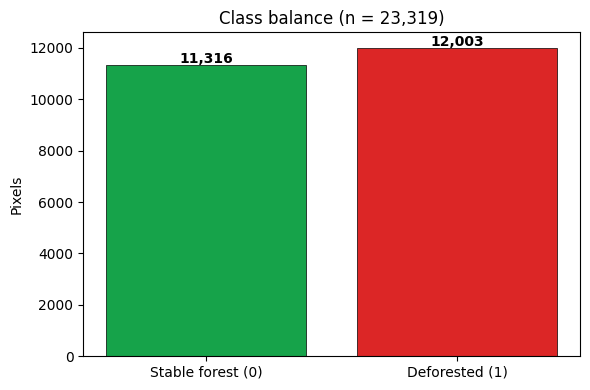

In [2]:
c = df['label'].value_counts().sort_index()
plt.figure(figsize=(6,4))
b = plt.bar(['Stable forest (0)','Deforested (1)'], c.values, color=[GREEN,RED], edgecolor='black', lw=.5)
for bar,v in zip(b,c.values): plt.text(bar.get_x()+bar.get_width()/2, v+80, f'{v:,}', ha='center', fontweight='bold')
plt.ylabel('Pixels'); plt.title(f'Class balance (n = {len(df):,})'); plt.tight_layout()
plt.savefig(OUT/'01_class_balance.png', dpi=150, bbox_inches='tight'); plt.show()

### 2 · Per-feature distributions by class
Box plots (median + IQR, outliers hidden). Features whose boxes separate by class
carry the most signal — note the radar (VH/VV) and NDVI_change columns.

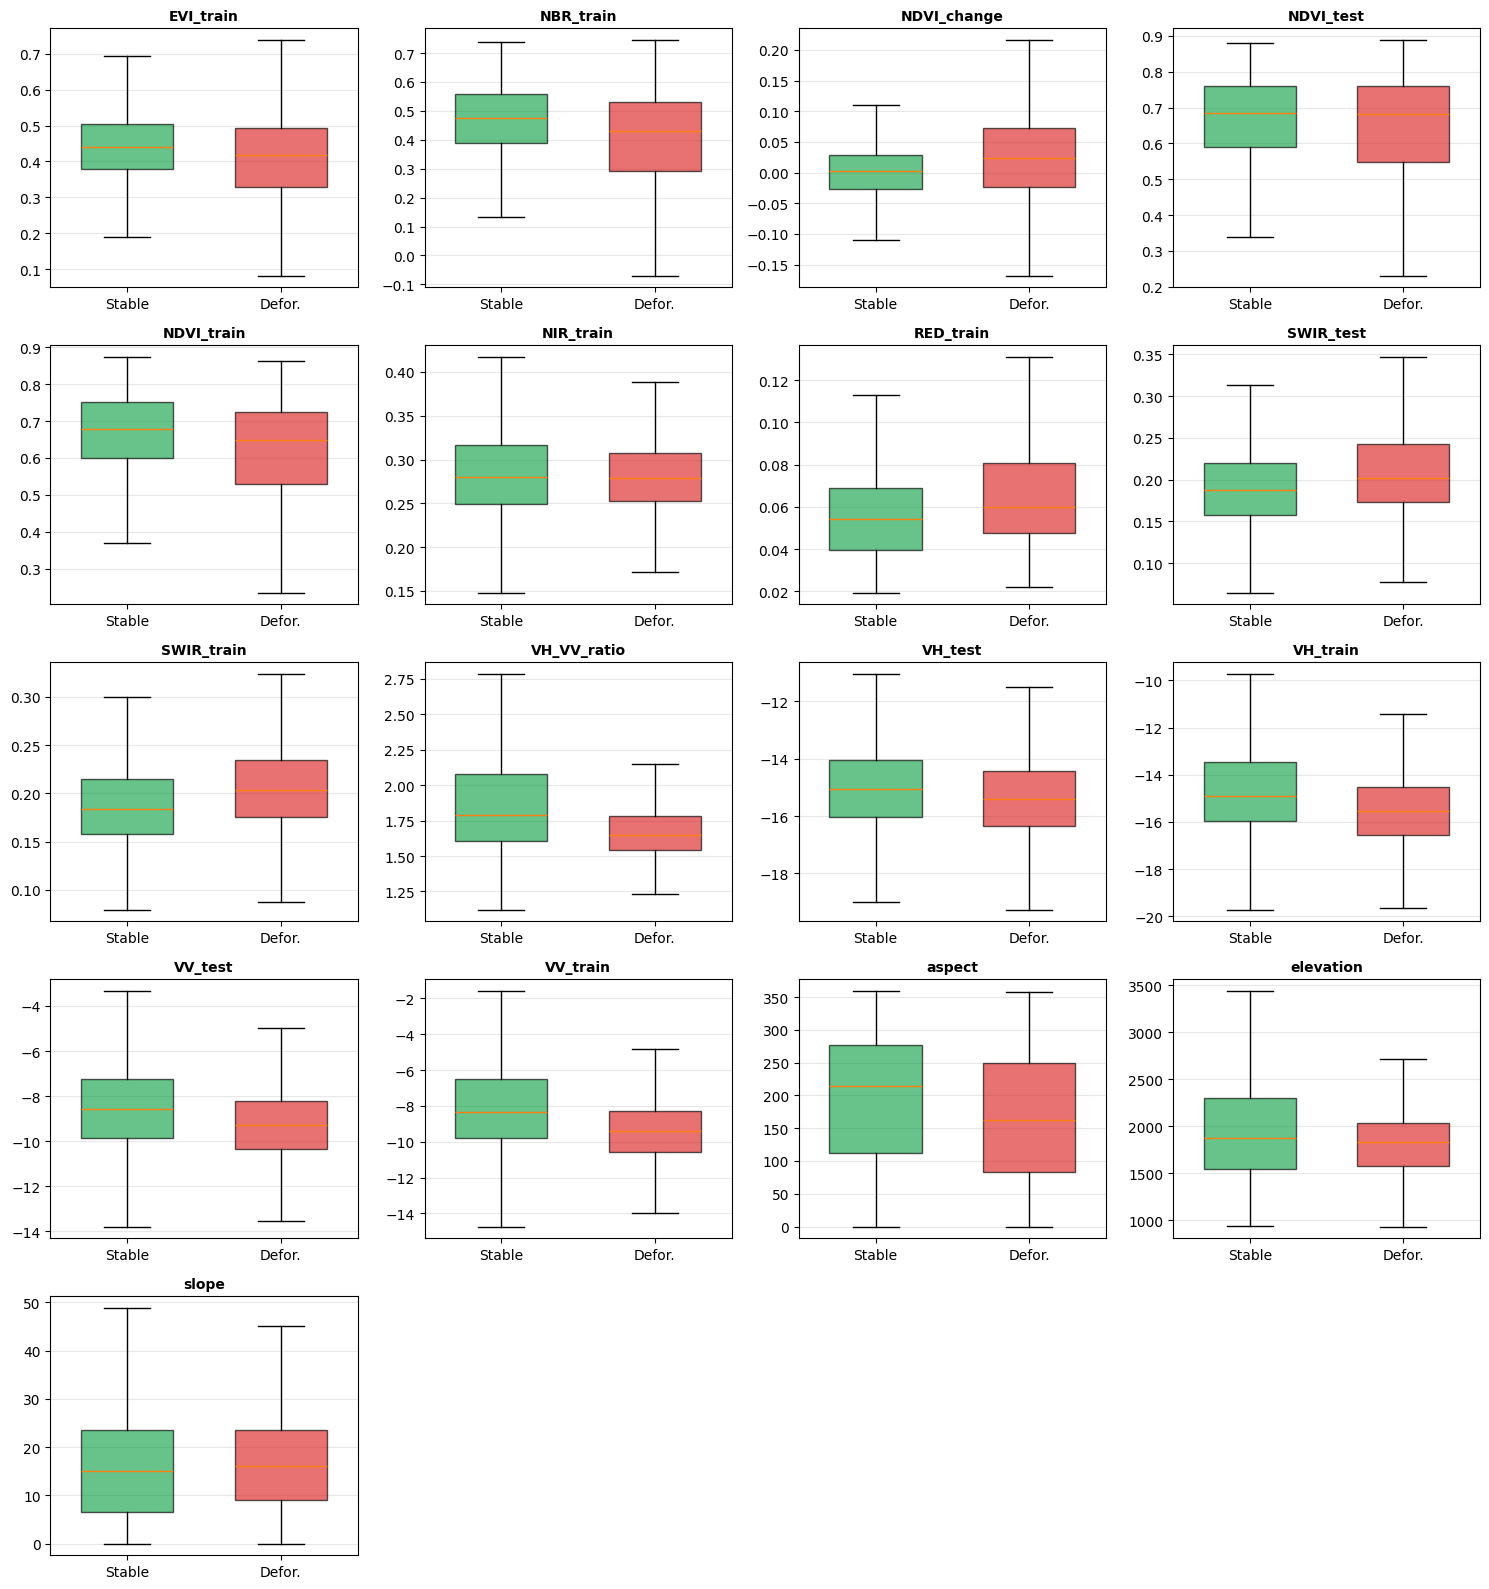

In [3]:
nrows = int(np.ceil(len(FEATURES)/4))
fig, ax = plt.subplots(nrows, 4, figsize=(15, 3.2*nrows)); ax = ax.flatten()
for i,f in enumerate(FEATURES):
    bp = ax[i].boxplot([X[y==0][f], X[y==1][f]], patch_artist=True, widths=.6,
                       tick_labels=['Stable','Defor.'], showfliers=False)
    for p,cl in zip(bp['boxes'],[GREEN,RED]): p.set_facecolor(cl); p.set_alpha(.65)
    ax[i].set_title(f, fontsize=10, fontweight='bold'); ax[i].grid(axis='y', alpha=.3)
for j in range(len(FEATURES), len(ax)): ax[j].set_visible(False)
plt.tight_layout(); plt.savefig(OUT/'02_feature_distributions.png', dpi=150, bbox_inches='tight'); plt.show()

### 3 · Feature correlation
Pearson correlation. |r| > 0.7 flags redundant pairs (e.g. paired train/test bands),
which the Random Forest tolerates but which motivate the feature-set comparison in RQ1.

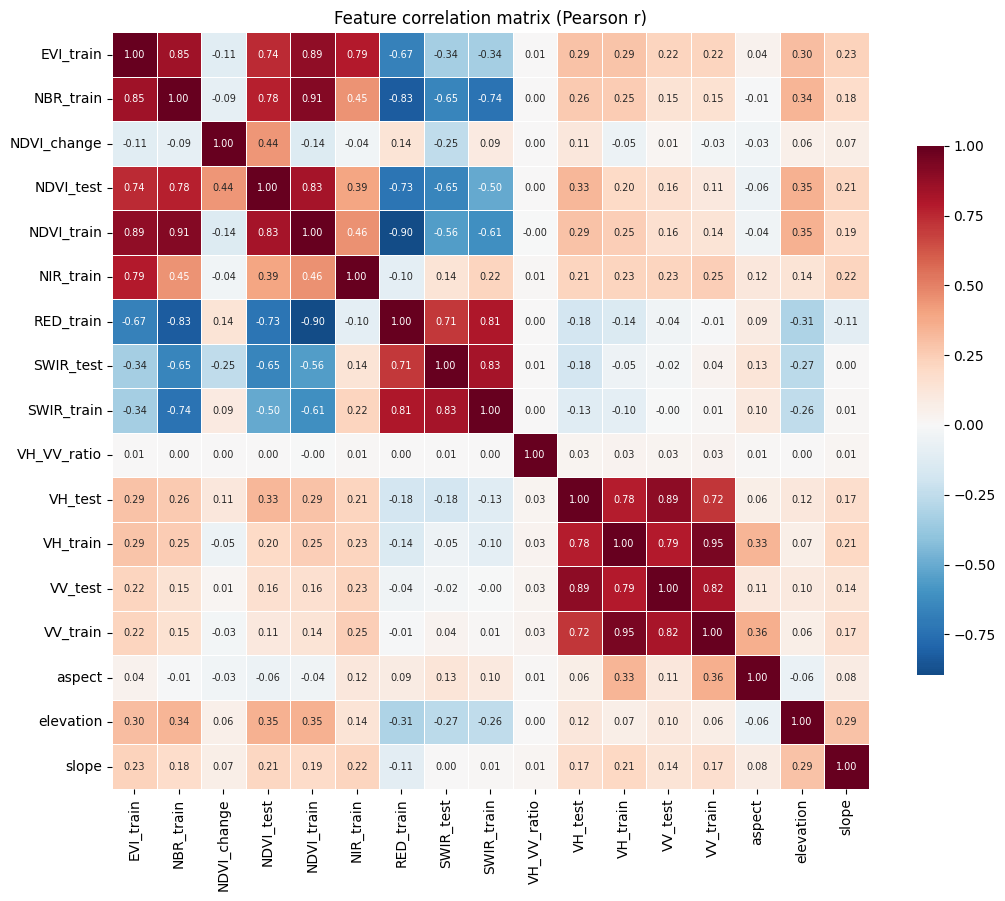

In [4]:
corr = X.corr()
plt.figure(figsize=(11,9))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdBu_r', center=0, square=True,
            linewidths=.5, annot_kws={'size':7}, cbar_kws={'shrink':.7})
plt.title('Feature correlation matrix (Pearson r)'); plt.tight_layout()
plt.savefig(OUT/'03_correlation_heatmap.png', dpi=150, bbox_inches='tight'); plt.show()

### 4 · PCA projection
The 17-D feature space projected to 2-D. Partial class separation confirms the
features are informative but not linearly separable — justifying a non-linear model.

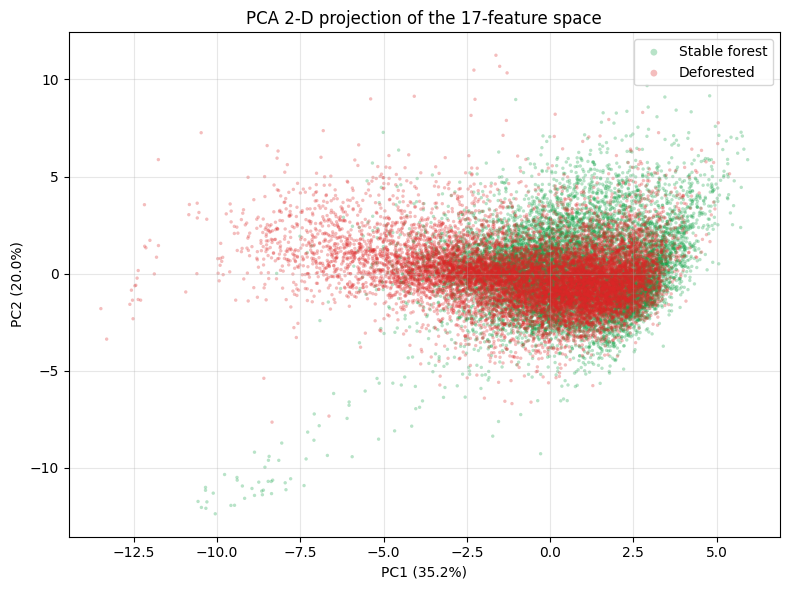

In [5]:
Xp = PCA(n_components=2, random_state=42).fit(StandardScaler().fit_transform(X))
Z = Xp.transform(StandardScaler().fit_transform(X))
plt.figure(figsize=(8,6))
for lbl,cl,name in [(0,GREEN,'Stable forest'),(1,RED,'Deforested')]:
    plt.scatter(Z[y==lbl,0], Z[y==lbl,1], s=6, alpha=.3, c=cl, label=name, edgecolors='none')
plt.xlabel(f'PC1 ({Xp.explained_variance_ratio_[0]*100:.1f}%)')
plt.ylabel(f'PC2 ({Xp.explained_variance_ratio_[1]*100:.1f}%)')
plt.title('PCA 2-D projection of the 17-feature space'); plt.legend(markerscale=2); plt.grid(alpha=.3)
plt.tight_layout(); plt.savefig(OUT/'04_pca_scatter.png', dpi=150, bbox_inches='tight'); plt.show()

### 5 · Spatial distribution
Both classes are spread across all five provinces (province-stratified sampling),
so the model is not learning a single region.

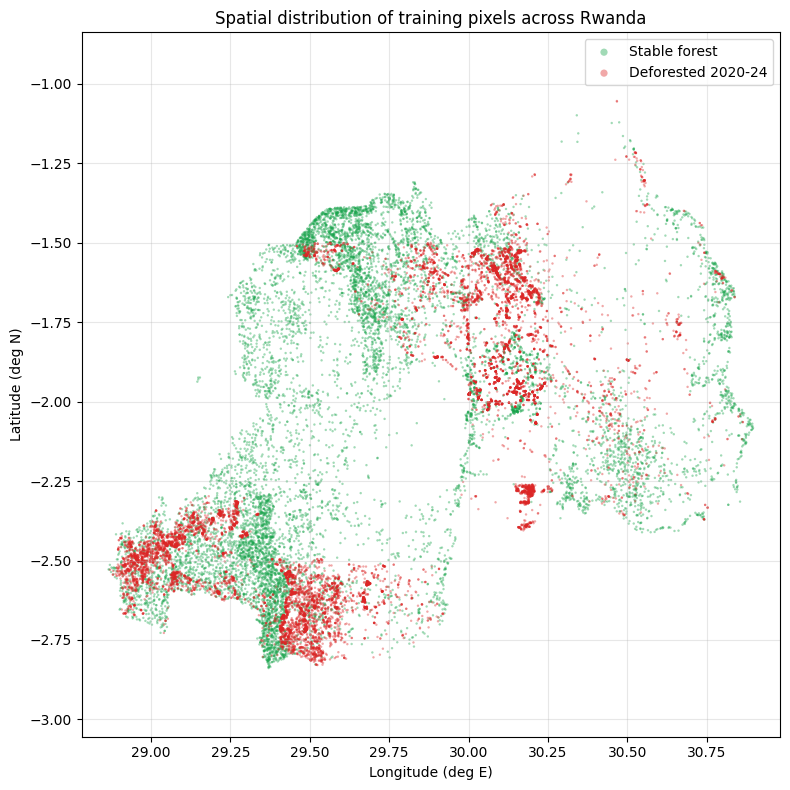

In [6]:
plt.figure(figsize=(8,8))
for lbl,cl,name in [(0,GREEN,'Stable forest'),(1,RED,'Deforested 2020-24')]:
    s = df[df.label==lbl]; plt.scatter(s.lng, s.lat, s=3, alpha=.4, c=cl, label=name, edgecolors='none')
plt.xlabel('Longitude (deg E)'); plt.ylabel('Latitude (deg N)')
plt.title('Spatial distribution of training pixels across Rwanda')
plt.legend(markerscale=3); plt.gca().set_aspect('equal', adjustable='datalim'); plt.grid(alpha=.3)
plt.tight_layout(); plt.savefig(OUT/'05_spatial_distribution.png', dpi=150, bbox_inches='tight'); plt.show()

### 6 · Precision-Recall curve
For a balanced binary task, PR complements ROC. A quick Random Forest on a held-out
split gives the average-precision baseline the deployed model builds on.

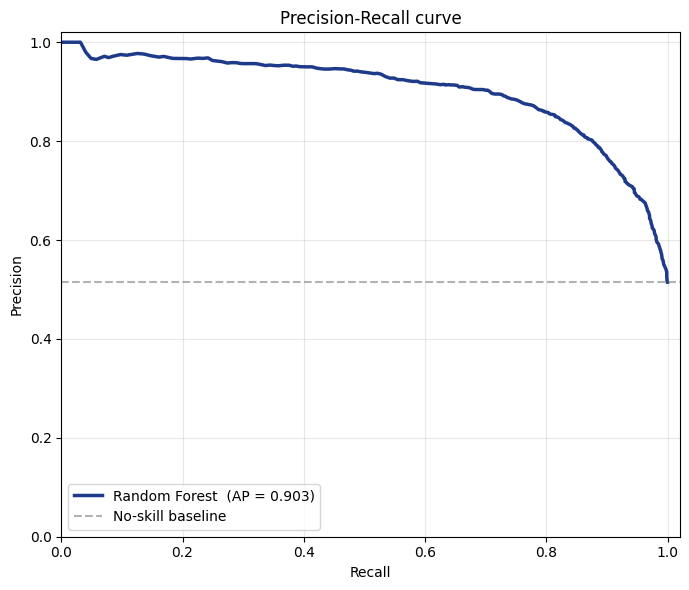

Average Precision = 0.903


In [7]:
Xtr,Xte,ytr,yte = train_test_split(X, y, test_size=.2, stratify=y, random_state=42)
proba = RandomForestClassifier(n_estimators=300, n_jobs=-1, random_state=42).fit(Xtr,ytr).predict_proba(Xte)[:,1]
prec,rec,_ = precision_recall_curve(yte, proba); ap = average_precision_score(yte, proba)
plt.figure(figsize=(7,6))
plt.plot(rec, prec, color='#1e3a8a', lw=2.5, label=f'Random Forest  (AP = {ap:.3f})')
plt.axhline(y[y==1].size/y.size, ls='--', c='grey', alpha=.6, label='No-skill baseline')
plt.xlabel('Recall'); plt.ylabel('Precision'); plt.xlim(0,1.02); plt.ylim(0,1.02)
plt.title('Precision-Recall curve'); plt.legend(loc='lower left'); plt.grid(alpha=.3)
plt.tight_layout(); plt.savefig(OUT/'06_precision_recall.png', dpi=150, bbox_inches='tight'); plt.show()
print(f'Average Precision = {ap:.3f}')